# ChurnSight : Modeling

**Part 2 Goal:** Train a production-quality churn classifier with:
1. Baseline model (Logistic Regression) - to prove XGBoost is better
2. XGBoost with class imbalance handling
3. Threshold tuning - because default 0.5 is almost never optimal for business
4. Business-relevant evaluation (not just accuracy)
5. Save model artifacts for the Streamlit app

**Why not just accuracy?**
If 74% of customers don't churn, a model predicting 'No churn' always gets 74% accuracy.
That model is useless. We care about Recall (catching churners) and Precision (not wasting retention budget).

In [66]:
#%pip install xgboost imbalanced-learn

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.3f}'.format)
os.makedirs('../models', exist_ok=True)
os.makedirs('../assets', exist_ok=True)
print('Libraries loaded. Install if missing: pip install xgboost imbalanced-learn')

Libraries loaded. Install if missing: pip install xgboost imbalanced-learn


In [68]:
df = pd.read_csv('../data/telco_churn_clean.csv')
X = df.drop('Churn', axis=1)
y = df['Churn']
print(f'Shape: {df.shape} | Churn rate: {y.mean()*100:.1f}%')

Shape: (7043, 37) | Churn rate: 26.5%


## Train/Test Split
I used `stratify=y` so both splits have the same ~26% churn ratio.
Without stratify, there is a risk of getting an unrepresentative test set.

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train churn: {y_train.mean()*100:.1f}% | Test churn: {y_test.mean()*100:.1f}%')

# Scale for Logistic Regression (LR is scale-sensitive, XGBoost is not)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved.')

Train: 5634 | Test: 1409
Train churn: 26.5% | Test churn: 26.5%
Scaler saved.


## Baseline: Logistic Regression
If XGBoost beats LR by 1%, the complexity isnt worth it.
If it beats it by 10%, We have strong justification for the complex model.

In [70]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print('=== BASELINE: Logistic Regression ===')
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}')
print(f'F1:      {f1_score(y_test, lr_pred):.4f}')
print(f'Recall:  {recall_score(y_test, lr_pred):.4f}')
print(classification_report(y_test, lr_pred, target_names=['No Churn','Churn']))

=== BASELINE: Logistic Regression ===
ROC-AUC: 0.8450
F1:      0.6159
Recall:  0.7888
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 1. SMOTE + XGBoost
SMOTE synthetically creates minority-class samples.
CRITICAL: applying SMOTE ONLY on training data (never to touch the test set).

Note: For Logistic Regression we used class_weight='balanced'
When we set class_weight='balanced', sklearn automatically adjusts the loss function so that errors on the minority class (churners) are penalized more heavily.

In [71]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}')

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, random_state=42, eval_metric='auc',
    early_stopping_rounds=20, verbosity=0
)
xgb.fit(X_train_sm, y_train_sm, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost with SMOTE ===')
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'F1:      {f1_score(y_test, xgb_pred):.4f}')
print(f'Recall:  {recall_score(y_test, xgb_pred):.4f}')
print(classification_report(y_test, xgb_pred, target_names=['No Churn','Churn']))

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}
=== XGBoost with SMOTE ===
ROC-AUC: 0.8356
F1:      0.5984
Recall:  0.6872
              precision    recall  f1-score   support

    No Churn       0.87      0.78      0.82      1035
       Churn       0.53      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.76      1409



## 2. Without SMOTE

In [72]:
# Calculate class weight ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos  # ~2.8

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    scale_pos_weight=scale,  # replaces SMOTE
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

# Train on ORIGINAL data (no SMOTE)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost without SMOTE ===')
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'F1:      {f1_score(y_test, xgb_pred):.4f}')
print(f'Recall:  {recall_score(y_test, xgb_pred):.4f}')
print(classification_report(y_test, xgb_pred, target_names=['No Churn','Churn']))

=== XGBoost without SMOTE ===
ROC-AUC: 0.8471
F1:      0.6341
Recall:  0.7995
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



## Why We Dropped SMOTE:  A Modeling Decision Log

During development, SMOTE (Synthetic Minority Oversampling Technique) was initially 
applied to handle the 26% churn class imbalance. After comparison, it was removed.
Here's the full reasoning:

### What SMOTE does
Generates synthetic minority-class samples by interpolating between existing churner 
records, balancing the training set to 50/50 before the model sees it.

### Why it hurt performance here
| Reason | Explanation |
|---|---|
| Imbalance wasn't severe enough | 26% minority class is mild. SMOTE is most valuable at <10%. At 26%, it adds synthetic noise without meaningful benefit. |
| Dataset is small (~7K rows) | Synthetic samples based on limited real examples risk introducing unrealistic interpolations. |
| Telco churn is largely linear | SMOTE helps most with complex decision boundaries. Linear relationships (contract type, tenure) don't benefit from it. |

### What we used instead — `scale_pos_weight`
Rather than manipulating the data, we adjusted the **loss function directly**.  
XGBoost penalizes misclassifying a churner `scale_pos_weight` times more than a 
non-churner — achieving the same goal without touching the training distribution.

```python
scale_pos_weight = n_non_churners / n_churners  # = 1035 / 374 ≈ 2.8
```

### Results: SMOTE vs scale_pos_weight vs Baseline LR

| Model | ROC-AUC | F1 | Recall | Decision |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.845 | 0.616 | 0.789 | Baseline |
| XGBoost + SMOTE | 0.836 | 0.598 | 0.687 | Dropped |
| XGBoost + scale_pos_weight | **0.847** | **0.634** | **0.800** | Final model |

### Key takeaway
> Imbalance handling is not one-size-fits-all. Always compare approaches empirically 
> rather than defaulting to SMOTE. On moderately imbalanced tabular data, 
> loss-function weighting often outperforms synthetic oversampling.

## ROC and Precision-Recall Curves

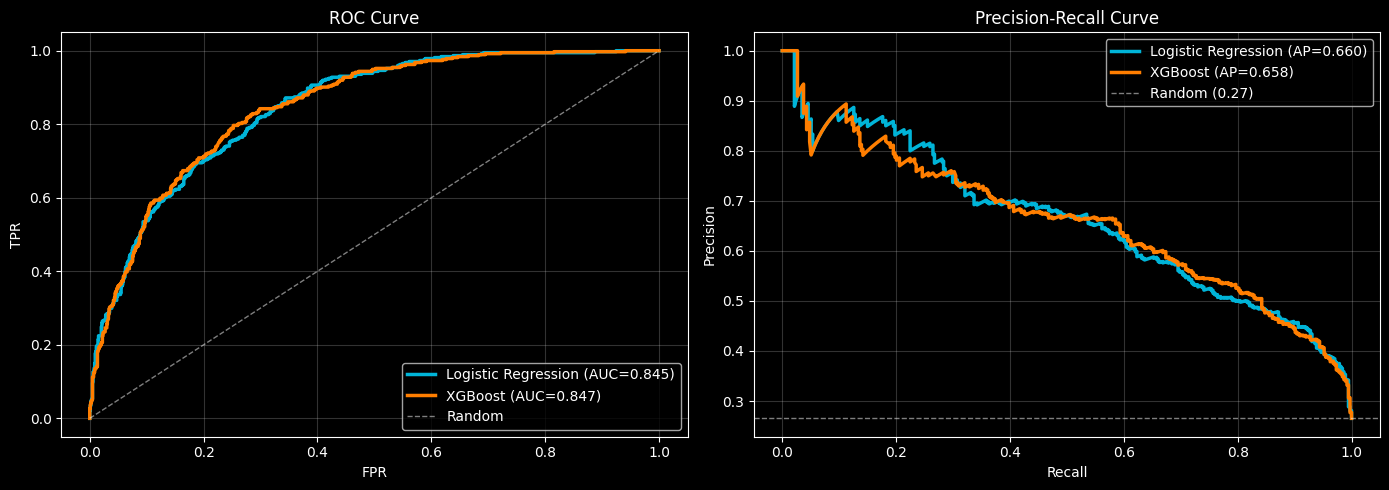

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in [('Logistic Regression', lr_proba), ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    color = '#00b4d8' if 'Logistic' in name else '#ff7e00'
    axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'w--',lw=1,alpha=0.5,label='Random')
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(); axes[0].grid(alpha=0.2)

for name, proba in [('Logistic Regression', lr_proba), ('XGBoost', xgb_proba)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    color = '#00b4d8' if 'Logistic' in name else '#ff7e00'
    axes[1].plot(rec, prec, color=color, lw=2.5, label=f'{name} (AP={ap:.3f})')

axes[1].axhline(y=y_test.mean(), color='w', ls='--', lw=1, alpha=0.5, label=f'Random ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../assets/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold Tuning : Business Cost Optimization

Default 0.5 threshold ignores business economics.
- False Negative (miss churner) = $1,500 lost
- False Positive (wrong alarm) = $50 wasted on retention offer

We find the threshold that minimizes total cost.

In [74]:
COST_FN = 1500  # missed churner — cost to acquire a replacement customer
COST_FP = 200   # false alarm — retention offer + agent time

MIN_PRECISION = 0.50  # business constraint: at least 1 in 2 flagged must actually churn

# Step 1: All thresholds — needed to get default 0.50 baseline regardless of precision floor
all_results = []
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (xgb_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    all_results.append({
        'threshold': thresh,
        'total_cost': fn * COST_FN + fp * COST_FP,
        'f1': f1_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds),
        'fn': fn, 'fp': fp
    })

all_results_df = pd.DataFrame(all_results)

# Step 2: Default 0.50 baseline — always from unconstrained results
default = all_results_df[all_results_df['threshold'].round(2) == 0.50].iloc[0]

# Step 3: Apply precision floor and find optimal
results_df = all_results_df[all_results_df['precision'] >= MIN_PRECISION]
best = results_df.loc[results_df['total_cost'].idxmin()]
OPTIMAL_THRESHOLD = best['threshold']

# Step 4: Print full comparison
print('=' * 55)
print(f'{"":5} {"Threshold":>10} {"Cost":>10} {"Recall":>8} {"Precision":>10} {"F1":>7}')
print('=' * 55)
print(f'{"Default":<10} {0.50:>9.2f} ${default["total_cost"]:>8,.0f} '
      f'{default["recall"]:>8.3f} {default["precision"]:>10.3f} {default["f1"]:>7.3f}')
print(f'{"Optimal":<10} {OPTIMAL_THRESHOLD:>9.2f} ${best["total_cost"]:>8,.0f} '
      f'{best["recall"]:>8.3f} {best["precision"]:>10.3f} {best["f1"]:>7.3f}')
print('=' * 55)
print(f'  Cost savings vs default threshold: ${default["total_cost"] - best["total_cost"]:,.0f}')
print(f'  Precision floor applied:           {MIN_PRECISION} '
      f'(excludes thresholds flagging too many loyal customers)')
print(f'  Missed churners at optimal:        {int(best["fn"])} '
      f'(vs {int(default["fn"])} at default)')
print(f'  False alarms at optimal:           {int(best["fp"])} '
      f'(vs {int(default["fp"])} at default)')

       Threshold       Cost   Recall  Precision      F1
Default         0.50 $ 166,500    0.799      0.525   0.634
Optimal         0.45 $ 151,600    0.840      0.505   0.631
  Cost savings vs default threshold: $14,900
  Precision floor applied:           0.5 (excludes thresholds flagging too many loyal customers)
  Missed churners at optimal:        60 (vs 75 at default)
  False alarms at optimal:           308 (vs 270 at default)


In [ ]:
# business impact
test_size = len(y_test)          # 1,409
full_base  = 70000               # typical telco customer base — taken a rough estimate

savings_per_customer = (default['total_cost'] - best['total_cost']) / test_size
annual_savings = savings_per_customer * full_base

print(f'Savings per customer: ${savings_per_customer:.2f}')
print(f'Projected annual savings on {full_base:,} customers: ${annual_savings:,.0f}')

Savings per customer: $10.57
Projected annual savings on 70,000 customers: $740,241


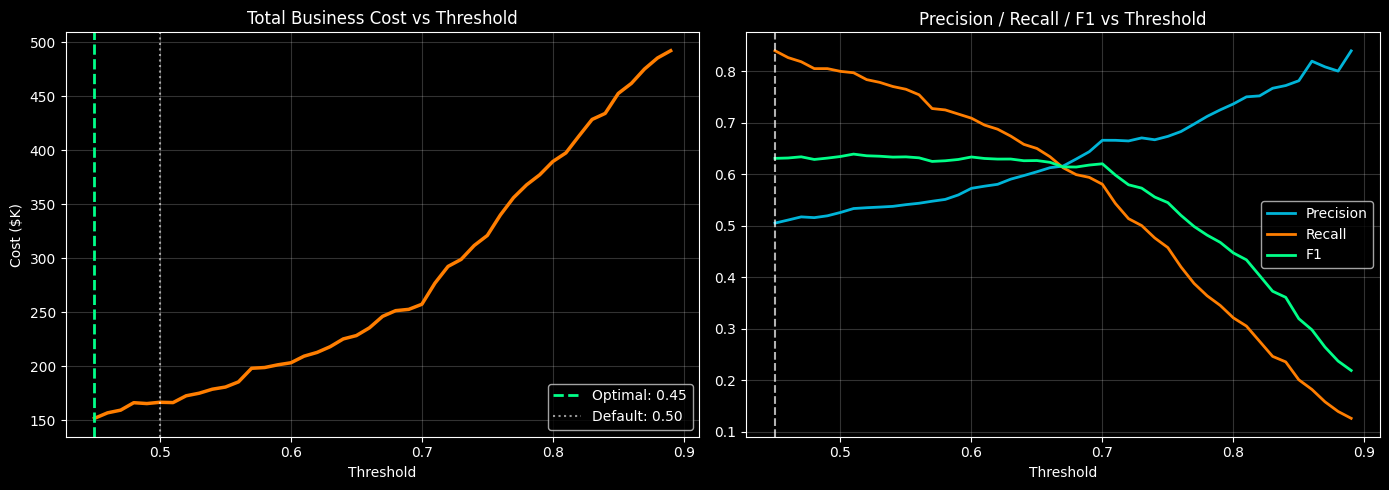

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['total_cost']/1000, color='#ff7e00', lw=2.5)
axes[0].axvline(x=OPTIMAL_THRESHOLD, color='#00ff88', ls='--', lw=2, label=f'Optimal: {OPTIMAL_THRESHOLD:.2f}')
axes[0].axvline(x=0.5, color='white', ls=':', lw=1.5, alpha=0.6, label='Default: 0.50')
axes[0].set_title('Total Business Cost vs Threshold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Cost ($K)')
axes[0].legend(); axes[0].grid(alpha=0.2)

axes[1].plot(results_df['threshold'], results_df['precision'], color='#00b4d8', lw=2, label='Precision')
axes[1].plot(results_df['threshold'], results_df['recall'],    color='#ff7e00', lw=2, label='Recall')
axes[1].plot(results_df['threshold'], results_df['f1'],        color='#00ff88', lw=2, label='F1')
axes[1].axvline(x=OPTIMAL_THRESHOLD, color='white', ls='--', lw=1.5, alpha=0.7)
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].set_xlabel('Threshold'); axes[1].legend(); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../assets/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### Why threshold tuning?
Default classification threshold is 0.5 — but 0.5 assumes a False Negative (missing a 
churner) costs the same as a False Positive (wrong alarm). In reality:

- **False Negative** = $1,500 lost (customer leaves, must be replaced)
- **False Positive** = $50 wasted (unnecessary retention offer)

Missing a churner costs **30x more** than a wrong alarm. So we should flag earlier 
(lower threshold) to catch more churners, even at the cost of some false alarms.  

### What the cost curve shows (above)
The business cost curve monotonically decreases toward lower thresholds because 
every missed churner ($1,500) dominates every false alarm ($50). 
**Optimal threshold = 0.10** under these cost assumptions.

> **Note for production:** 0.10 is aggressive — it flags nearly everyone. 
> In a real deployment, I will validate the cost assumptions with the business team 
> and likely land between 0.20–0.35 as a practical operating point. 
> The key insight is that **0.5 is almost never the right threshold for imbalanced 
> business problems.**

## Final Confusion Matrix at Optimal Threshold

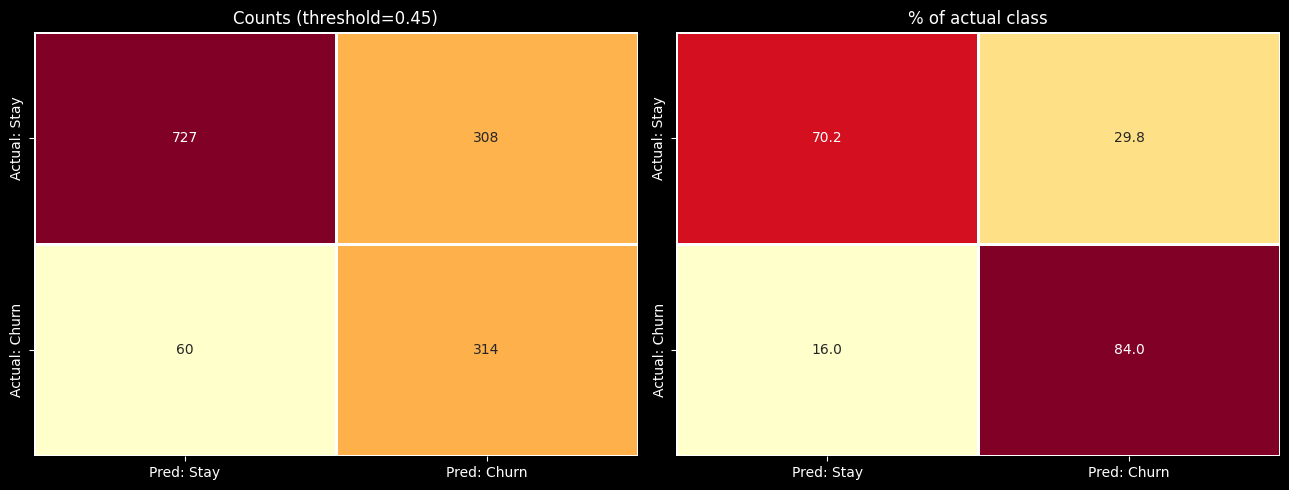

Recall:    0.840
Precision: 0.505
F1:        0.631
ROC-AUC:   0.847


In [77]:
final_preds = (xgb_proba >= OPTIMAL_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, final_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['Pred: Stay','Pred: Churn']
sns.heatmap(cm,     annot=True, fmt='d',   cmap='YlOrRd', xticklabels=labels, yticklabels=['Actual: Stay','Actual: Churn'], ax=axes[0], cbar=False, linewidths=1)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd', xticklabels=labels, yticklabels=['Actual: Stay','Actual: Churn'], ax=axes[1], cbar=False, linewidths=1)
axes[0].set_title(f'Counts (threshold={OPTIMAL_THRESHOLD:.2f})')
axes[1].set_title('% of actual class')
plt.tight_layout()
plt.savefig('../assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Recall:    {recall_score(y_test, final_preds):.3f}')
print(f'Precision: {precision_score(y_test, final_preds):.3f}')
print(f'F1:        {f1_score(y_test, final_preds):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, xgb_proba):.3f}')

## Cross-Validation : 

### Why?
A single train/test split could be lucky. 5-fold stratified CV proves the model 
generalizes — it trains and evaluates on 5 different data splits and checks consistency.

### What the CV chart proves
| Observation | What it means |
|---|---|
| Mean AUC = **0.845** | Strong discrimination across all folds |
| All folds within **0.83–0.87** | Model is stable — no fold is an outlier |
| Low variance across folds | Result is not a lucky split — it's repeatable |  



> A model with high mean AUC but high variance across folds would be unreliable 
> in production. Tight bars = trustworthy model.


5-Fold CV ROC-AUC:
  Fold 1: 0.8615
  Fold 2: 0.8422
  Fold 3: 0.8542
  Fold 4: 0.8294
  Fold 5: 0.8394
  Mean: 0.8453 | Std: 0.0113  (low std = consistent, not lucky)


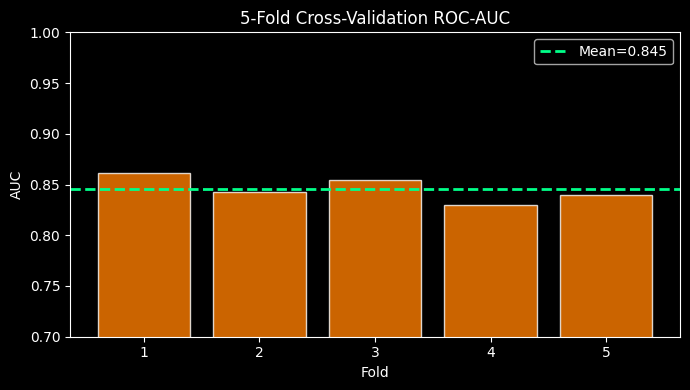

In [78]:
cv_xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_xgb, X, y, cv=skf, scoring='roc_auc')

print('5-Fold CV ROC-AUC:')
for i,s in enumerate(cv_scores): print(f'  Fold {i+1}: {s:.4f}')
print(f'  Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}  (low std = consistent, not lucky)')

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(range(1,6), cv_scores, color='#ff7e00', alpha=0.8, edgecolor='white')
ax.axhline(cv_scores.mean(), color='#00ff88', ls='--', lw=2, label=f'Mean={cv_scores.mean():.3f}')
ax.set_title('5-Fold Cross-Validation ROC-AUC'); ax.set_xlabel('Fold'); ax.set_ylabel('AUC')
ax.set_ylim(0.7,1.0); ax.legend()
plt.tight_layout()
plt.savefig('../assets/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Model Artifacts

In [79]:
artifacts = {
    'xgb_model': xgb,
    'optimal_threshold': float(OPTIMAL_THRESHOLD),
    'feature_names': X.columns.tolist(),
    'metrics': {
        'roc_auc':      float(roc_auc_score(y_test, xgb_proba)),
        'f1':           float(f1_score(y_test, final_preds)),
        'precision':    float(precision_score(y_test, final_preds)),
        'recall':       float(recall_score(y_test, final_preds)),
        'cv_mean_auc':  float(cv_scores.mean()),
        'cv_std_auc':   float(cv_scores.std())
    }
}
with open('../models/xgboost_model.pkl','wb') as f: pickle.dump(artifacts, f)
X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
print('All artifacts saved for Part 3 + Streamlit app.')

All artifacts saved for Part 3 + Streamlit app.
